In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install timm medpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 15.0 MB/s eta 0:00:00


In [ ]:
!pip install timm -q

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from timm.models.layers import DropPath
from medpy.metric.binary import hd95, asd

In [ ]:
torch.backends.cudnn.benchmark = True

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

Device: cuda


In [ ]:
data_root = "/content/drive/MyDrive/ISIC 2017"

image_folder = os.path.join(data_root, "ISIC-2017_Validation")
mask_folder = os.path.join(data_root, "ISIC-2017_Validation_GroundTruth")

print("Image folder exists:", os.path.exists(image_folder))
print("Mask folder exists :", os.path.exists(mask_folder))

Image folder exists: True
Mask folder exists : True


In [ ]:
def build_pairs(image_folder, mask_folder):
    image_files = sorted([
        f for f in os.listdir(image_folder)
        if f.lower().endswith(".jpg") and not f.startswith(".")
    ])

    mask_files = set([
        f for f in os.listdir(mask_folder)
        if f.lower().endswith(".png") and not f.startswith(".")
    ])

    pairs = []
    missing_masks = []

    for img_name in image_files:
        base = os.path.splitext(img_name)[0]
        mask_name = base + "_segmentation.png"

        img_path = os.path.join(image_folder, img_name)
        mask_path = os.path.join(mask_folder, mask_name)

        if mask_name in mask_files:
            pairs.append((img_path, mask_path))
        else:
            missing_masks.append((img_name, mask_name))

    print("JPG images found   :", len(image_files))
    print("PNG masks found    :", len(mask_files))
    print("Valid pairs found  :", len(pairs))
    print("Missing masks count:", len(missing_masks))

    if missing_masks:
        print("\nFirst 10 missing examples:")
        for item in missing_masks[:10]:
            print(item)

    return pairs

pairs = build_pairs(image_folder, mask_folder)

JPG images found   : 150
PNG masks found    : 150
Valid pairs found  : 150
Missing masks count: 0


In [ ]:
random.shuffle(pairs)
pairs = pairs[:150]
print("Using subset size:", len(pairs))

Using subset size: 150


In [ ]:
train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Train:", len(train_pairs))
print("Val  :", len(val_pairs))
print("Test :", len(test_pairs))

Train: 105
Val  : 22
Test : 23


In [ ]:
class ISICSegDataset(Dataset):
    def __init__(self, pairs, image_size=128, train=False):
        self.pairs = pairs
        self.image_size = image_size
        self.train = train

        self.mean = [0.485, 0.456, 0.406]
        self.std = [0.229, 0.224, 0.225]

    def __len__(self):
        return len(self.pairs)

    def augment(self, image, mask):
        if random.random() > 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        if random.random() > 0.5:
            image = TF.vflip(image)
            mask = TF.vflip(mask)

        if random.random() > 0.5:
            angle = random.choice([90, 180, 270])
            image = TF.rotate(image, angle)
            mask = TF.rotate(mask, angle)

        return image, mask

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = image.resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)

        if self.train:
            image, mask = self.augment(image, mask)

        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=self.mean, std=self.std)

        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()

        return image, mask

In [ ]:
IMAGE_SIZE = 256
BATCH_SIZE = 4
NUM_WORKERS = 2

train_dataset = ISICSegDataset(train_pairs, image_size=IMAGE_SIZE, train=True)
val_dataset   = ISICSegDataset(val_pairs, image_size=IMAGE_SIZE, train=False)
test_dataset  = ISICSegDataset(test_pairs, image_size=IMAGE_SIZE, train=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 27
Val batches  : 6
Test batches : 6


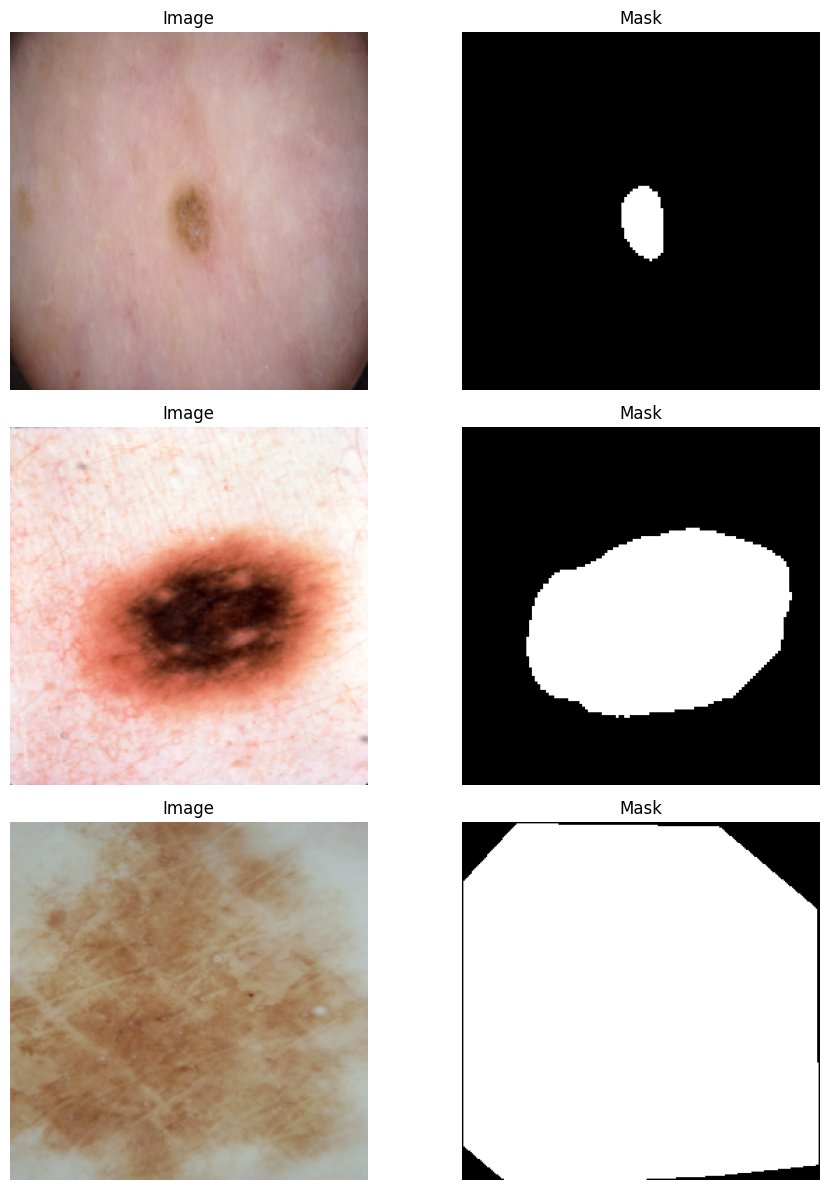

In [ ]:
def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    img = img * std + mean
    return np.clip(img, 0, 1)

def show_samples(dataset, n=3):
    plt.figure(figsize=(10, 4 * n))

    for i in range(n):
        image, mask = dataset[i]
        image_np = denormalize(image.numpy()).transpose(1, 2, 0)
        mask_np = mask.squeeze().numpy()

        plt.subplot(n, 2, 2 * i + 1)
        plt.imshow(image_np)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(n, 2, 2 * i + 2)
        plt.imshow(mask_np, cmap="gray")
        plt.title("Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train_dataset, n=3)

In [ ]:
import torch
import torch.nn as nn
from timm.models.layers import DropPath

BNNorm2d = nn.BatchNorm2d
Activation = nn.GELU


class up_conv(nn.Module):
    def __init__(self, ch_in, ch_out):
        super().__init__()
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(ch_in, ch_out, kernel_size=3, stride=1, padding=1, bias=False),
            BNNorm2d(ch_out),
            Activation()
        )

    def forward(self, x):
        return self.up(x)


class down_conv(nn.Module):
    def __init__(self, ch_in, ch_out):
        super().__init__()
        self.down = nn.Sequential(
            nn.Conv2d(ch_in, ch_out, kernel_size=3, stride=2, padding=1, bias=False),
            BNNorm2d(ch_out),
            Activation()
        )

    def forward(self, x):
        return self.down(x)


class MSCA(nn.Module):
    def __init__(self, channels):
        super().__init__()

        # local depthwise conv
        self.conv0 = nn.Conv2d(
            channels, channels,
            kernel_size=5, padding=2,
            groups=channels, bias=False
        )

        # branch 1 -> 7x7
        self.branch1_1 = nn.Conv2d(
            channels, channels,
            kernel_size=(1, 7), padding=(0, 3),
            groups=channels, bias=False
        )
        self.branch1_2 = nn.Conv2d(
            channels, channels,
            kernel_size=(7, 1), padding=(3, 0),
            groups=channels, bias=False
        )

        # branch 2 -> 11x11
        self.branch2_1 = nn.Conv2d(
            channels, channels,
            kernel_size=(1, 11), padding=(0, 5),
            groups=channels, bias=False
        )
        self.branch2_2 = nn.Conv2d(
            channels, channels,
            kernel_size=(11, 1), padding=(5, 0),
            groups=channels, bias=False
        )

        # branch 3 -> 15x15
        self.branch3_1 = nn.Conv2d(
            channels, channels,
            kernel_size=(1, 15), padding=(0, 7),
            groups=channels, bias=False
        )
        self.branch3_2 = nn.Conv2d(
            channels, channels,
            kernel_size=(15, 1), padding=(7, 0),
            groups=channels, bias=False
        )

        self.channel_mix = nn.Conv2d(channels, channels, kernel_size=1, bias=False)

    def forward(self, x):
        attn = self.conv0(x)

        attn1 = self.branch1_2(self.branch1_1(attn))
        attn2 = self.branch2_2(self.branch2_1(attn))
        attn3 = self.branch3_2(self.branch3_1(attn))

        attn = attn + attn1 + attn2 + attn3
        attn = self.channel_mix(attn)
        return attn


class LSB(nn.Module):
    """
    Local Semantic Block following proposal:
    3x3 Conv -> BN -> GELU -> 3x3 Conv -> BN -> MSCA -> Residual Add -> GELU
    """
    def __init__(self, inplanes, planes, groups=1):
        super().__init__()
        self.inplanes = inplanes
        self.planes = planes

        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = BNNorm2d(planes)
        self.act = Activation()

        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, groups=groups, bias=False)
        self.bn2 = BNNorm2d(planes)

        self.msca = MSCA(planes)

        if inplanes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(inplanes, planes, kernel_size=1, stride=1, bias=False),
                BNNorm2d(planes)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.act(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = self.msca(out)   # MSCA before residual addition
        out = out + identity
        out = self.act(out)

        return out


class OPE(nn.Module):
    def __init__(self, inplanes, planes):
        super().__init__()
        self.conv1 = nn.Conv2d(inplanes, inplanes, 3, stride=1, padding=1, bias=False)
        self.bn1 = BNNorm2d(inplanes)
        self.act = Activation()
        self.down = down_conv(inplanes, planes)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.act(out)
        out = self.down(out)
        return out


class local_block(nn.Module):
    def __init__(self, inplanes, hidden_planes, planes, groups=1, down_or_up=None):
        super().__init__()

        self.lsb = LSB(inplanes=inplanes, planes=hidden_planes, groups=groups)

        if down_or_up is None:
            self.change = nn.Identity()
        elif down_or_up == 'down':
            self.change = down_conv(hidden_planes, planes)
        elif down_or_up == 'up':
            self.change = up_conv(hidden_planes, planes)
        else:
            raise ValueError("down_or_up must be None, 'down', or 'up'")

    def forward(self, x):
        out = self.lsb(x)
        out = self.change(out)
        return out


class Pooling(nn.Module):
    def __init__(self, pool_size=3):
        super().__init__()
        self.pool = nn.AvgPool2d(
            pool_size,
            stride=1,
            padding=pool_size // 2,
            count_include_pad=False
        )

    def forward(self, x):
        return self.pool(x) - x


class GroupNorm(nn.GroupNorm):
    def __init__(self, num_channels, **kwargs):
        super().__init__(1, num_channels, **kwargs)


class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features, out_features, drop=0.):
        super().__init__()
        self.fc1 = nn.Conv2d(in_features, hidden_features, 1)
        self.act = Activation()
        self.fc2 = nn.Conv2d(hidden_features, out_features, 1)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class global_block(nn.Module):
    def __init__(self, in_dim, dim, num_heads, pool_size=3, mlp_ratio=4., drop=0., drop_path=0., sr_ratio=1):
        super().__init__()

        self.proj = nn.Conv2d(in_dim, dim, kernel_size=3, padding=1, bias=False)
        self.norm1 = GroupNorm(dim)
        self.attn = Pooling(pool_size=pool_size)
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = GroupNorm(dim)

        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim, out_features=dim, drop=drop)

    def forward(self, x):
        x = self.proj(x)
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class WNet2D_MSCA(nn.Module):
    def __init__(self, in_channel=3, num_classes=1, deep_supervised=False,
                 layer_channel=[16, 32, 64, 128, 256],
                 global_dim=[8, 16, 32, 64, 128],
                 num_heads=[1, 2, 4, 8],
                 sr_ratio=[8, 4, 2, 1]):
        super().__init__()
        self.deep_supervised = deep_supervised

        self.input_l0 = nn.Sequential(
            nn.Conv2d(in_channel, layer_channel[0], kernel_size=3, stride=1, padding=1, bias=False),
            BNNorm2d(layer_channel[0]),
            Activation(),
            nn.Conv2d(layer_channel[0], layer_channel[0], kernel_size=3, stride=1, padding=1, bias=False),
            BNNorm2d(layer_channel[0]),
            Activation()
        )

        self.encoder1_l1_local = OPE(layer_channel[0], layer_channel[1])
        self.encoder1_l1_global = global_block(layer_channel[0], global_dim[0], num_heads=num_heads[0], sr_ratio=sr_ratio[0])

        self.encoder1_l2_local = OPE(layer_channel[1], layer_channel[2])
        self.encoder1_l2_global = global_block(layer_channel[1], global_dim[1], num_heads=num_heads[1], sr_ratio=sr_ratio[1])

        self.encoder1_l3_local = OPE(layer_channel[2], layer_channel[3])
        self.encoder1_l3_global = global_block(layer_channel[2], global_dim[2], num_heads=num_heads[2], sr_ratio=sr_ratio[2])

        self.encoder1_l4_local = OPE(layer_channel[3], layer_channel[4])
        self.encoder1_l4_global = global_block(layer_channel[3], global_dim[3], num_heads=num_heads[3], sr_ratio=sr_ratio[3])

        self.decoder1_l4_local = local_block(layer_channel[4], layer_channel[4], layer_channel[3], down_or_up='up')
        self.decoder1_l4_global = global_block(layer_channel[4], global_dim[4], num_heads=num_heads[3], sr_ratio=sr_ratio[3])

        self.decoder1_l3_local = local_block(layer_channel[3] + global_dim[3], layer_channel[3], layer_channel[2], down_or_up='up')
        self.decoder1_l3_global = global_block(layer_channel[3] + global_dim[3], global_dim[3], num_heads=num_heads[2], sr_ratio=sr_ratio[2])

        self.decoder1_l2_local = local_block(layer_channel[2] + global_dim[2], layer_channel[2], layer_channel[1], down_or_up='up')
        self.decoder1_l2_global = global_block(layer_channel[2] + global_dim[2], global_dim[2], num_heads=num_heads[1], sr_ratio=sr_ratio[1])

        self.decoder1_l1_local = local_block(layer_channel[1] + global_dim[1], layer_channel[1], layer_channel[0], down_or_up='up')
        self.decoder1_l1_global = global_block(layer_channel[1] + global_dim[1], global_dim[1], num_heads=num_heads[0], sr_ratio=sr_ratio[0])

        self.encoder2_l1_local = local_block(layer_channel[0] + global_dim[0], layer_channel[0], layer_channel[1], down_or_up='down')
        self.encoder2_l1_global = global_block(layer_channel[0] + global_dim[0], global_dim[0], num_heads=num_heads[0], sr_ratio=sr_ratio[0])

        self.encoder2_l2_local = local_block(layer_channel[1] + global_dim[1], layer_channel[1], layer_channel[2], down_or_up='down')
        self.encoder2_l2_global = global_block(layer_channel[1] + global_dim[1], global_dim[1], num_heads=num_heads[1], sr_ratio=sr_ratio[1])

        self.encoder2_l3_local = local_block(layer_channel[2] + global_dim[2], layer_channel[2], layer_channel[3], down_or_up='down')
        self.encoder2_l3_global = global_block(layer_channel[2] + global_dim[2], global_dim[2], num_heads=num_heads[2], sr_ratio=sr_ratio[2])

        self.encoder2_l4_local = local_block(layer_channel[3] + global_dim[3], layer_channel[3], layer_channel[4], down_or_up='down')
        self.encoder2_l4_global = global_block(layer_channel[3] + global_dim[3], global_dim[3], num_heads=num_heads[3], sr_ratio=sr_ratio[3])

        self.decoder2_l4_local_output = nn.Conv2d(layer_channel[4], num_classes, kernel_size=1, stride=1, padding=0)
        self.decoder2_l4_local = local_block(layer_channel[4] + global_dim[4], layer_channel[4], layer_channel[3], down_or_up='up')

        self.decoder2_l3_local_output = nn.Conv2d(layer_channel[3], num_classes, kernel_size=1, stride=1, padding=0)
        self.decoder2_l3_local = local_block(layer_channel[3] + global_dim[3], layer_channel[3], layer_channel[2], down_or_up='up')

        self.decoder2_l2_local_output = nn.Conv2d(layer_channel[2], num_classes, kernel_size=1, stride=1, padding=0)
        self.decoder2_l2_local = local_block(layer_channel[2] + global_dim[2], layer_channel[2], layer_channel[1], down_or_up='up')

        self.decoder2_l1_local_output = nn.Conv2d(layer_channel[1], num_classes, kernel_size=1, stride=1, padding=0)
        self.decoder2_l1_local = local_block(layer_channel[1] + global_dim[1], layer_channel[1], layer_channel[0], down_or_up='up')

        self.output_l0 = nn.Sequential(
            local_block(layer_channel[0] + global_dim[0], layer_channel[0], layer_channel[0], down_or_up=None),
            nn.Conv2d(layer_channel[0], num_classes, kernel_size=1, stride=1, padding=0)
        )

    def forward(self, x):
        outputs = []

        x_e1_l0 = self.input_l0(x)

        x_e1_l1_local = self.encoder1_l1_local(x_e1_l0)
        x_e1_l0_global = self.encoder1_l1_global(x_e1_l0)

        x_e1_l2_local = self.encoder1_l2_local(x_e1_l1_local)
        x_e1_l1_global = self.encoder1_l2_global(x_e1_l1_local)

        x_e1_l3_local = self.encoder1_l3_local(x_e1_l2_local)
        x_e1_l2_global = self.encoder1_l3_global(x_e1_l2_local)

        x_e1_l4_local = self.encoder1_l4_local(x_e1_l3_local)
        x_e1_l3_global = self.encoder1_l4_global(x_e1_l3_local)

        x_d1_l3_local = self.decoder1_l4_local(x_e1_l4_local)
        x_d1_l4_global = self.decoder1_l4_global(x_e1_l4_local)

        x_d1_l3 = torch.cat((x_d1_l3_local, x_e1_l3_global), dim=1)
        x_d1_l2_local = self.decoder1_l3_local(x_d1_l3)
        x_d1_l3_global = self.decoder1_l3_global(x_d1_l3)

        x_d1_l2 = torch.cat((x_d1_l2_local, x_e1_l2_global), dim=1)
        x_d1_l1_local = self.decoder1_l2_local(x_d1_l2)
        x_d1_l2_global = self.decoder1_l2_global(x_d1_l2)

        x_d1_l1 = torch.cat((x_d1_l1_local, x_e1_l1_global), dim=1)
        x_d1_l0_local = self.decoder1_l1_local(x_d1_l1)
        x_d1_l1_global = self.decoder1_l1_global(x_d1_l1)

        x_e2_l0 = torch.cat((x_d1_l0_local, x_e1_l0_global), dim=1)
        x_e2_l1_local = self.encoder2_l1_local(x_e2_l0)
        x_e2_l0_global = self.encoder2_l1_global(x_e2_l0)

        x_e2_l1 = torch.cat((x_e2_l1_local, x_d1_l1_global), dim=1)
        x_e2_l2_local = self.encoder2_l2_local(x_e2_l1)
        x_e2_l1_global = self.encoder2_l2_global(x_e2_l1)

        x_e2_l2 = torch.cat((x_e2_l2_local, x_d1_l2_global), dim=1)
        x_e2_l3_local = self.encoder2_l3_local(x_e2_l2)
        x_e2_l2_global = self.encoder2_l3_global(x_e2_l2)

        x_e2_l3 = torch.cat((x_e2_l3_local, x_d1_l3_global), dim=1)
        x_e2_l4_local = self.encoder2_l4_local(x_e2_l3)
        x_e2_l3_global = self.encoder2_l4_global(x_e2_l3)

        outputs.append(self.decoder2_l4_local_output(x_e2_l4_local))
        x_e2_l4 = torch.cat((x_e2_l4_local, x_d1_l4_global), dim=1)
        x_d2_l3_local = self.decoder2_l4_local(x_e2_l4)

        outputs.append(self.decoder2_l3_local_output(x_d2_l3_local))
        x_d2_l3 = torch.cat((x_d2_l3_local, x_e2_l3_global), dim=1)
        x_d2_l2_local = self.decoder2_l3_local(x_d2_l3)

        outputs.append(self.decoder2_l2_local_output(x_d2_l2_local))
        x_d2_l2 = torch.cat((x_d2_l2_local, x_e2_l2_global), dim=1)
        x_d2_l1_local = self.decoder2_l2_local(x_d2_l2)

        outputs.append(self.decoder2_l1_local_output(x_d2_l1_local))
        x_d2_l1 = torch.cat((x_d2_l1_local, x_e2_l1_global), dim=1)
        x_d2_l0_local = self.decoder2_l1_local(x_d2_l1)

        x_d2_l0 = torch.cat((x_d2_l0_local, x_e2_l0_global), dim=1)
        outputs.append(self.output_l0(x_d2_l0))

        outputs = outputs[::-1]

        if self.deep_supervised:
            return outputs
        return outputs[0]

In [ ]:
model = WNet2D_MSCA(
    in_channel=3,
    num_classes=1,
    deep_supervised=False,
    layer_channel=[8, 16, 32, 64, 128],
    global_dim=[4, 8, 16, 32, 64]
).to(cfg.device)
x = torch.randn(1, 3, cfg.image_size, cfg.image_size).to(cfg.device)
y = model(x)
print("Output shape:", y.shape)

Output shape: torch.Size([1, 1, 256, 256])


In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (probs * targets).sum(dim=1)
        union = probs.sum(dim=1) + targets.sum(dim=1)

        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        return self.bce(logits, targets) + self.dice(logits, targets)

criterion = BCEDiceLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_1470/4026270.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
def dice_score(preds, targets, smooth=1e-6):
    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1)

    dice = (2.0 * intersection + smooth) / (union + smooth)
    return dice.mean().item()

def iou_score(preds, targets, smooth=1e-6):
    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    iou = (intersection + smooth) / (union + smooth)
    return iou.mean().item()

def pixel_accuracy(preds, targets):
    correct = (preds == targets).float().sum()
    total = torch.numel(preds)
    return (correct / total).item()

def hd95_metric(preds, targets):
    vals = []
    preds = preds.cpu().numpy().astype(np.uint8)
    targets = targets.cpu().numpy().astype(np.uint8)

    for p, t in zip(preds, targets):
        p = p.squeeze()
        t = t.squeeze()
        if p.sum() > 0 and t.sum() > 0:
            vals.append(hd95(p, t))
    return np.mean(vals) if len(vals) > 0 else 0.0

def asd_metric(preds, targets):
    vals = []
    preds = preds.cpu().numpy().astype(np.uint8)
    targets = targets.cpu().numpy().astype(np.uint8)

    for p, t in zip(preds, targets):
        p = p.squeeze()
        t = t.squeeze()
        if p.sum() > 0 and t.sum() > 0:
            vals.append(asd(p, t))
    return np.mean(vals) if len(vals) > 0 else 0.0

In [ ]:
THRESHOLD = 0.5

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, desc="Training", leave=False)

    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    return {"loss": running_loss / len(loader)}


@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    running_acc = 0.0
    running_hd95 = 0.0
    running_asd = 0.0

    pbar = tqdm(loader, desc="Evaluating", leave=False)

    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, masks)

        probs = torch.sigmoid(outputs)
        preds = (probs > threshold).float()

        running_loss += loss.item()
        running_dice += dice_score(preds, masks)
        running_iou += iou_score(preds, masks)
        running_acc += pixel_accuracy(preds, masks)
        running_hd95 += hd95_metric(preds, masks)
        running_asd += asd_metric(preds, masks)

    n = len(loader)
    return {
        "loss": running_loss / n,
        "dice": running_dice / n,
        "iou": running_iou / n,
        "acc": running_acc / n,
        "hd95": running_hd95 / n,
        "asd": running_asd / n
    }

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
from torch.cuda.amp import GradScaler

scaler = GradScaler()



Using device: cuda


/tmp/ipykernel_1470/1530451386.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
EPOCHS = 100
SAVE_PATH = "/content/best_msca_lsb_isic.pth"

history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
    "val_acc": [],
    "val_hd95": [],
    "val_asd": []
}

best_val_dice = 0.0

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch + 1}/{EPOCHS}]")

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, val_loader, criterion, device, THRESHOLD)

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_dice"].append(val_metrics["dice"])
    history["val_iou"].append(val_metrics["iou"])
    history["val_acc"].append(val_metrics["acc"])
    history["val_hd95"].append(val_metrics["hd95"])
    history["val_asd"].append(val_metrics["asd"])

    scheduler.step(val_metrics["dice"])

    print(f"Train Loss: {train_metrics['loss']:.4f}")
    print(
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Dice: {val_metrics['dice']:.4f} | "
        f"IoU: {val_metrics['iou']:.4f} | "
        f"Acc: {val_metrics['acc']:.4f} | "
        f"95HD: {val_metrics['hd95']:.4f} | "
        f"ASD: {val_metrics['asd']:.4f}"
    )

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        torch.save(model.state_dict(), SAVE_PATH)
        print("Best model saved.")


Epoch [1/100]


Training:   0%|          | 0/27 [00:00<?, ?it/s]/tmp/ipykernel_1470/3416754549.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Train Loss: 1.4490
Val Loss: 1.4697 | Dice: 0.2270 | IoU: 0.1422 | Acc: 0.7713 | 95HD: 128.3969 | ASD: 73.5382
Best model saved.

Epoch [2/100]


Train Loss: 1.3382
Val Loss: 1.3313 | Dice: 0.3703 | IoU: 0.2682 | Acc: 0.7232 | 95HD: 119.1102 | ASD: 68.3812
Best model saved.

Epoch [3/100]


Train Loss: 1.2675
Val Loss: 1.2386 | Dice: 0.3710 | IoU: 0.2650 | Acc: 0.7161 | 95HD: 109.0820 | ASD: 61.2179
Best model saved.

Epoch [4/100]


...

Train Loss: 0.4042
Val Loss: 0.5597 | Dice: 0.7519 | IoU: 0.6633 | Acc: 0.8729 | 95HD: 33.1307 | ASD: 19.2357

Epoch [97/100]


Train Loss: 0.4030
Val Loss: 0.5478 | Dice: 0.7557 | IoU: 0.6693 | Acc: 0.8691 | 95HD: 31.0132 | ASD: 18.5750

Epoch [98/100]


Train Loss: 0.4067
Val Loss: 0.5515 | Dice: 0.7547 | IoU: 0.6663 | Acc: 0.8729 | 95HD: 31.8357 | ASD: 18.3022

Epoch [99/100]


Train Loss: 0.5025
Val Loss: 0.5507 | Dice: 0.7540 | IoU: 0.6683 | Acc: 0.8621 | 95HD: 32.6001 | ASD: 19.7455

Epoch [100/100]


Train Loss: 0.5279
Val Loss: 0.5074 | Dice: 0.7561 | IoU: 0.6660 | Acc: 0.8868 | 95HD: 31.9561 | ASD: 17.5507


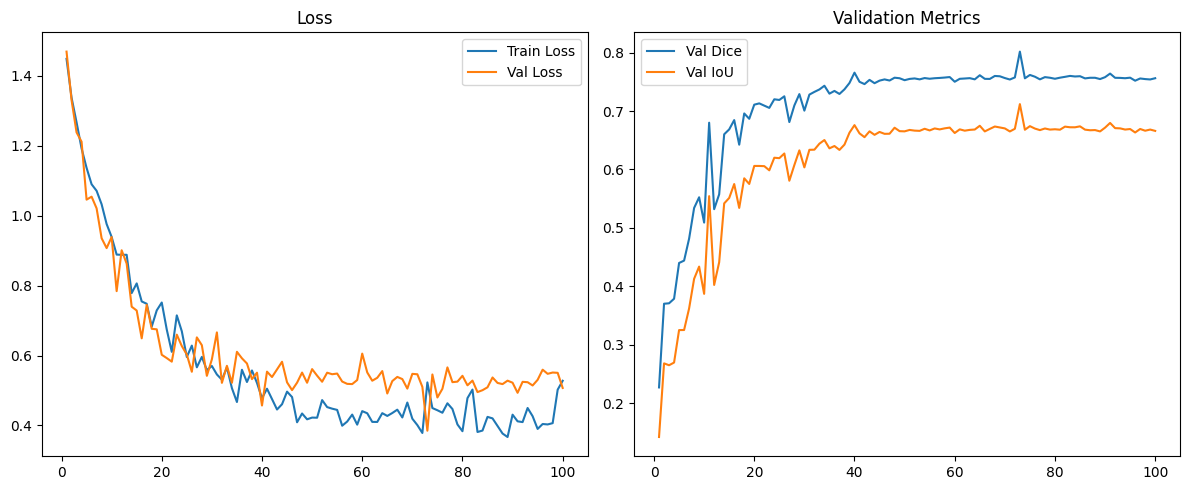

In [ ]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["val_dice"], label="Val Dice")
plt.plot(epochs_range, history["val_iou"], label="Val IoU")
plt.title("Validation Metrics")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()
print("Best model loaded.")

Best model loaded.


In [ ]:
test_metrics = evaluate(model, test_loader, criterion, device, THRESHOLD)

print("\nTest Results")
print(f"Loss : {test_metrics['loss']:.4f}")
print(f"Dice : {test_metrics['dice']:.4f}")
print(f"IoU  : {test_metrics['iou']:.4f}")
print(f"Acc  : {test_metrics['acc']:.4f}")
print(f"95HD : {test_metrics['hd95']:.4f}")
print(f"ASD  : {test_metrics['asd']:.4f}")


Test Results
Loss : 0.5013
Dice : 0.7380
IoU  : 0.6338
Acc  : 0.9277
95HD : 37.7054
ASD  : 14.7632


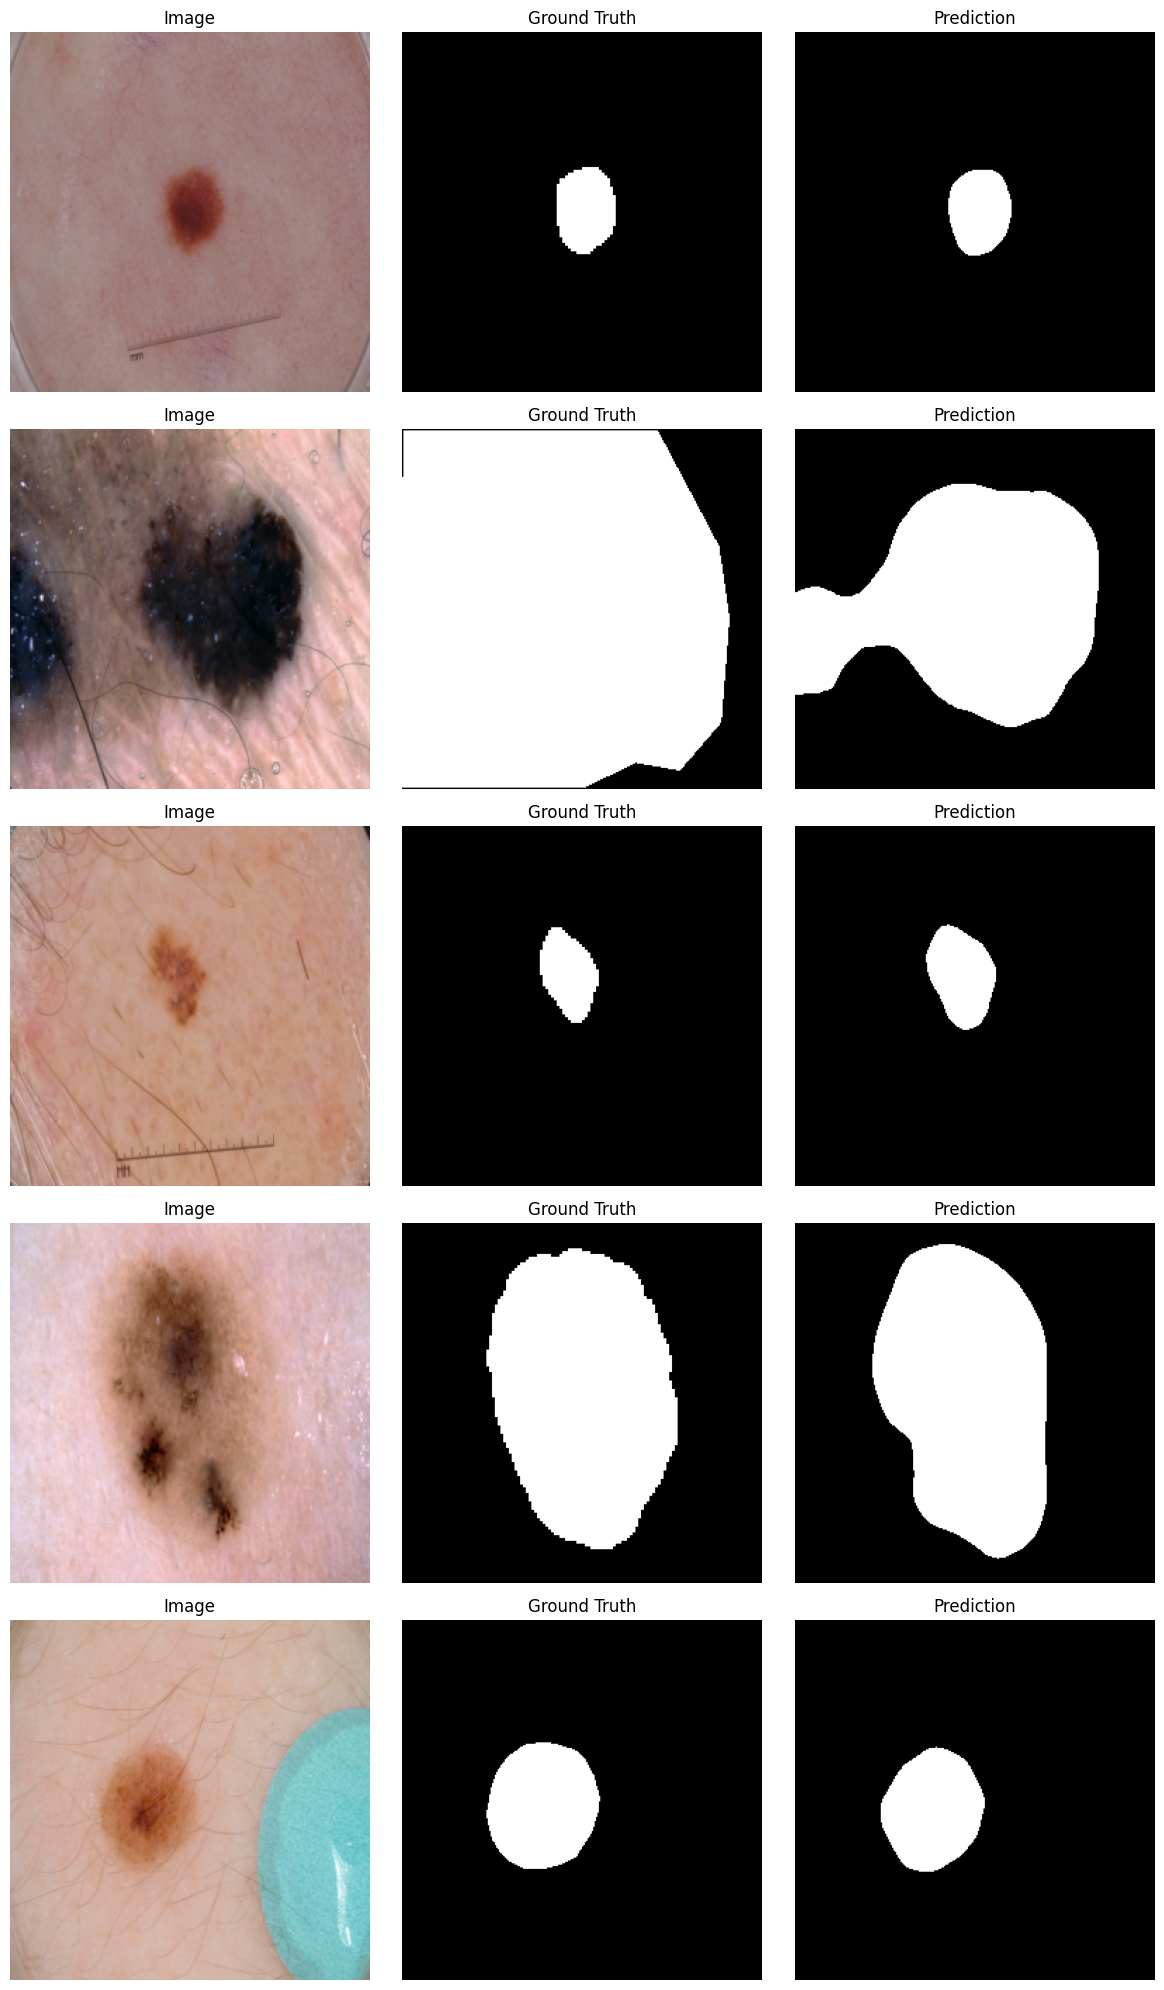

In [ ]:
@torch.no_grad()
def show_predictions(model, dataset, device, num_samples=5, threshold=0.5):
    model.eval()

    indices = np.random.choice(len(dataset), num_samples, replace=False)
    plt.figure(figsize=(12, 4 * num_samples))

    for i, idx in enumerate(indices):
        image, mask = dataset[idx]
        input_tensor = image.unsqueeze(0).to(device)

        output = model(input_tensor)
        prob = torch.sigmoid(output).squeeze().cpu().numpy()
        pred = (prob > threshold).astype(np.float32)

        image_np = denormalize(image.numpy()).transpose(1, 2, 0)
        mask_np = mask.squeeze().numpy()

        plt.subplot(num_samples, 3, 3 * i + 1)
        plt.imshow(image_np)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(num_samples, 3, 3 * i + 2)
        plt.imshow(mask_np, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(num_samples, 3, 3 * i + 3)
        plt.imshow(pred, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(model, test_dataset, cfg.device, num_samples=5, threshold=cfg.threshold)

In [ ]:
import pandas as pd

results_df = pd.DataFrame([test_metrics])
results_df

,loss,dice,iou,acc,hd95,asd
0,0.501283,0.738009,0.633806,0.927694,37.705422,14.763177


In [ ]:
results_df.to_csv("/content/isic_test_results1.csv", index=False)
print("Saved to /content/isic_test_results1.csv")

Saved to /content/isic_test_results1.csv
